#Colab Setup (Required for Google Colab)

**These cells are ONLY for running on Google Colab. Skip if running locally.**

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Create output directory in your Drive
OUTPUT_DIR = '/content/drive/MyDrive/my_tfrecords_2018'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Mounted at /content/drive
Output directory: /content/drive/MyDrive/my_tfrecords_2018


In [ ]:
# Clone the cGAN tutorial repository
!git clone https://github.com/snath-xoc/cGAN_tutorial.git
%cd cGAN_tutorial


Cloning into 'cGAN_tutorial'...
remote: Enumerating objects: 260, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 260 (delta 12), reused 11 (delta 11), pack-reused 242 (from 1)
Receiving objects: 100% (260/260), 7.54 MiB | 22.52 MiB/s, done.
Resolving deltas: 100% (133/133), done.
/content/cGAN_tutorial


In [ ]:
!pip install -q xarray netCDF4 gcsfs joblib pyyaml tensorflow cartopy

# Install proper crcmod for faster downloads
!pip uninstall -y crcmod
!pip install --no-cache-dir -U crcmod


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for crcmod: filename=crcmod-1.7-cp312-cp312-linux_x86_64.whl size=31833 sha256=12be0cd053a541bb0c6d14472a7151a06eaabb3471e10ef6537ab74cf2d9763f
  Stored in directory: /tmp/pip-ephem-wheel-cache-vid8h993/wheels/76/08/0b/caa8b1380122cbfe6a03eaccbec0f63c67e619af4e30ca5e2a
Successfully built crcmod


### Download Raw Climate Data from GCS Buckets

We'll download:
- **IFS forecast data**
- **IMERG satellite observations** (~25 GB)
- **Normalization constants** and static fields



In [ ]:
# choose which variables to download
# Option 1: All variables (
# FORECAST_VARIABLES = ['tp', 'cp', 't2m', 'tcwv', 'sp', 'v10', 'u10', 'cape', 'tclw', 'tciw', 'tcrw', 'tcw', 'ssr', 'mcc']

# Option 2: 4 variables only (
FORECAST_VARIABLES = ['tp', 't2m', 'tcwv', 'sp']

YEAR = 2018

print(f"Will download {len(FORECAST_VARIABLES)} variables: {FORECAST_VARIABLES}")

Will download 4 variables: ['tp', 't2m', 'tcwv', 'sp']


In [ ]:
# directories for raw data (in colab)
RAW_IFS_DIR = f"/content/raw_ifs/{YEAR}/"
RAW_IMERG_DIR = "/content/raw_imerg/"
CONSTANTS_DIR = "/content/constants/"

os.makedirs(RAW_IFS_DIR, exist_ok=True)
os.makedirs(RAW_IMERG_DIR, exist_ok=True)
os.makedirs(CONSTANTS_DIR, exist_ok=True)

In [ ]:
# Download IFS forecast data (7 minutes)
print(f" Downloading {len(FORECAST_VARIABLES)} variables")
print()

for var in FORECAST_VARIABLES:
    print(f"Downloading {var}.nc.")
    !gsutil -m cp gs://sewaa-ifs-train/{YEAR}/{var}.nc {RAW_IFS_DIR}

print("\nIFS data downloaded")
!ls -lh {RAW_IFS_DIR}


Copying gs://sewaa-ifs-train/2018/tp.nc...
\ [1/1 files][  6.2 GiB/  6.2 GiB] 100% Done  90.5 MiB/s ETA 00:00:00           
Operation completed over 1 objects/6.2 GiB.                                      
Copying gs://sewaa-ifs-train/2018/t2m.nc...
| [1/1 files][  6.8 GiB/  6.8 GiB] 100% Done  76.6 MiB/s ETA 00:00:00           
Operation completed over 1 objects/6.8 GiB.                                      
Copying gs://sewaa-ifs-train/2018/tcwv.nc...
| [1/1 files][  7.3 GiB/  7.3 GiB] 100% Done  85.0 MiB/s ETA 00:00:00           
Operation completed over 1 objects/7.3 GiB.                                      
Copying gs://sewaa-ifs-train/2018/sp.nc...
\ [1/1 files][  6.5 GiB/  6.5 GiB] 100% Done  85.0 MiB/s ETA 00:00:00           
Operation completed over 1 objects/6.5 GiB.                                      

IFS data downloaded
total 27G
-rw-r--r-- 1 root root 6.6G Mar 12 12:35 sp.nc
-rw-r--r-- 1 root root 6.8G Mar 12 12:32 t2m.nc
-rw-r--r-- 1 root root 7.4G Mar 12 12:33 tcwv.

In [ ]:
# Download IMERG observation data ( minutes)
print("Downloading IMERG observation data")
print()

!gsutil -m cp -r gs://bucket_shruti_imerg/6h/{YEAR}/ {RAW_IMERG_DIR}

print("\n IMERG data downloaded")
!ls {RAW_IMERG_DIR}{YEAR}/ | head -20



Copying gs://bucket_shruti_imerg/6h/2018/20180101_00.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180101_12.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180101_06.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180102_12.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180102_06.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180101_18.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180102_18.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180102_00.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180103_00.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180103_06.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180103_12.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180104_00.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180103_18.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180104_06.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180104_12.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180104_18.nc...
Copying gs://bucket_shruti_imerg/6h/2018/20180105_00.nc

In [ ]:
# Download normalization constants and static fields
print("Downloading constants (normalization, elev, lsm)")

!gsutil cp gs://sewaa-ifs-train/constants/FCSTNorm_IFS/FCSTNorm{YEAR}.pkl {CONSTANTS_DIR}
!gsutil cp gs://sewaa-ifs-train/constants/elev.nc {CONSTANTS_DIR}
!gsutil cp gs://sewaa-ifs-train/constants/lsm.nc {CONSTANTS_DIR}


!ls -lh {CONSTANTS_DIR}

Copying gs://sewaa-ifs-train/constants/FCSTNorm_IFS/FCSTNorm2018.pkl...
/ [1 files][  1.3 KiB/  1.3 KiB]                                                
Operation completed over 1 objects/1.3 KiB.                                      
Copying gs://sewaa-ifs-train/constants/elev.nc...
/ [1 files][541.8 KiB/541.8 KiB]                                                
Operation completed over 1 objects/541.8 KiB.                                    
Copying gs://sewaa-ifs-train/constants/lsm.nc...
/ [1 files][540.9 KiB/540.9 KiB]                                                
Operation completed over 1 objects/540.9 KiB.                                    
total 1.1M
-rw-r--r-- 1 root root 542K Mar 12 12:36 elev.nc
-rw-r--r-- 1 root root 1.4K Mar 12 12:36 FCSTNorm2018.pkl
-rw-r--r-- 1 root root 541K Mar 12 12:36 lsm.nc


### Create Configuration Files

Set up paths to point to our downloaded data.

In [ ]:
# Create data_paths.yaml configuration
data_paths_content = f"""ICPAC_CLOUD:
  GENERAL:
    FORECAST_PATH: "/content/raw_ifs/"
    TRUTH_PATH: "/content/raw_imerg/"
    CONSTANTS_PATH: "{CONSTANTS_DIR}"

  TFRecords:
    tfrecords_path: "{OUTPUT_DIR}/"
"""

local_config_content = """data_paths: 'ICPAC_CLOUD'
"""

with open('config/data_paths.yaml', 'w') as f:
    f.write(data_paths_content)

with open('config/local_config.yaml', 'w') as f:
    f.write(local_config_content)

# Import functions and set TF_USE_LEGACY_KERAS = 1 (necessary only for tensorflow version >= 2.16.0)

In [ ]:
import os

# Only needed for tensorflow versions greater than 2.16.0
# os.environ["TF_USE_LEGACY_KERAS"] = "1"

import sys
import joblib
sys.path.insert(1,"../")
from data import write_data, gen_fcst_norm
import numpy as np
from config import get_data_paths

### Override all_fcst_fields



In [ ]:
# Patch the data module to use only the downloaded variables
import data
from datetime import datetime, timedelta

data.all_fcst_fields = FORECAST_VARIABLES

# (original version checks if files exist)
def get_dates_all(year, start_hour, end_hour):
    """Generate all dates for the year"""
    start_date = datetime(year, 1, 1)
    end_date = datetime(year, 12, 31)
    dates = []
    current = start_date
    while current <= end_date:
        dates.append(current.strftime('%Y%m%d'))
        current += timedelta(days=1)
    return dates

data.get_dates = get_dates_all


print(f"   Variables: {data.all_fcst_fields}")

   Variables: ['tp', 't2m', 'tcwv', 'sp']


## We retrieve the data paths set in [**config/data_paths.yaml**](https://github.com/snath-xoc/cGAN_tutorial/blob/main/config/data_paths.yaml) and check that they are correctly set. We also set the year that is used to generate normalisation constants

In [ ]:
data_paths = get_data_paths()
CONSTANTS_PATH = data_paths["GENERAL"]["CONSTANTS_PATH"]
FCSTNorm_year = "2018"

print("Sanity check that these data paths are correctly set:\n")
print("FORECAST_PATH:",data_paths["GENERAL"]["FORECAST_PATH"])
print("CONSTANTS_PATH:",data_paths["GENERAL"]["CONSTANTS_PATH"])
print("TRUTH_PATH:",data_paths["GENERAL"]["TRUTH_PATH"])
print("TFRecords path:",data_paths["TFRecords"]["tfrecords_path"])

Sanity check that these data paths are correctly set:

FORECAST_PATH: /content/raw_ifs/
CONSTANTS_PATH: /content/constants/
TRUTH_PATH: /content/raw_imerg/
TFRecords path: /content/drive/MyDrive/my_tfrecords_2018/


# Forecast normalisation constants
### Typically for AI approaches, training and optimisation as well as inference works best when the values are normalised in a manner that retains the original distirbution. We therefore calculate a set of forecast normalisation constants for the region with which to normalise the variables with. These normalisation constants include the mean, std, min and max.

### We normalise accordingly:
#### a) Precipitation variables of total precipitation (tp) and convective precipitation (cp) follow a log normalisation (i.e. log10(1+x) ).
#### b) 2m temperature (t2m) and surface pressure (sp) are reasonable normally distributed so we use a simple standard normalisation of (x-mean)/std.
#### c) Other variables are bounded to be non-negative (e.g., cape, tclw, tciw, tcrw, tcwv,tcw) and divided through by their maximum: x/max.
#### d) Wind (both u and v components) can be negative and are therefore divided by their absolute maximum: x/maxima(abs(min),abs(max)).
#### e) It is worth noting that Shortwave Solar Radiation (ssr) is an accumulated variables and needs to be converted from per second to per hour (i.e. x/3600).
#### f) Medium Cloud Cover (mcc) does not require any normalisation (as it is a fractional value bounded at 0-1).

##Mean, STD, min, max

In [ ]:
if not os.path.exists(CONSTANTS_PATH+f"FCSTNorm{FCSTNorm_year}.pkl"):
    gen_fcst_norm(year=FCSTNorm_year)
    fcstNorm = joblib.load(CONSTANTS_PATH+f"FCSTNorm{FCSTNorm_year}.pkl")
else:
    fcstNorm = joblib.load(CONSTANTS_PATH+f"FCSTNorm{FCSTNorm_year}.pkl")

print(fcstNorm)

{'cape': {'min': np.float32(0.0), 'max': np.float32(12028.97), 'mean': np.float64(372.25190070517834), 'std': np.float64(634.6625669909214)}, 'cp': {'min': np.float32(0.0), 'max': np.float32(11.575001), 'mean': np.float64(0.07430827387592304), 'std': np.float64(0.15727741289177508)}, 'mcc': {'min': np.float32(0.0), 'max': np.float32(1.0), 'mean': np.float64(0.1449043023444736), 'std': np.float64(0.15871610393337535)}, 'sp': {'min': np.float32(65720.24), 'max': np.float32(103549.266), 'mean': np.float64(94920.06952099419), 'std': np.float64(5503.212221379535)}, 'ssr': {'min': np.float32(-0.0431156), 'max': np.float32(924.5827), 'mean': np.float64(196.8274811061243), 'std': np.float64(235.30287313931277)}, 't2m': {'min': np.float32(270.85034), 'max': np.float32(321.96042), 'mean': np.float64(298.3595823336004), 'std': np.float64(5.641285692771801)}, 'tciw': {'min': np.float32(0.0), 'max': np.float32(2.5885322), 'mean': np.float64(0.014063224684635873), 'std': np.float64(0.028363458486443

# Data Generator
### As mentioned in the data module directory, a key part to the data load-in is the ```DataGenerator``` class from the [**data/data_generator.py**](https://github.com/snath-xoc/cGAN_tutorial/blob/main/data/data_generator.py) file.

### The ```DataGenerator``` calls the ```load_fcst_truth_batch``` function from [**data/data.py**](https://github.com/snath-xoc/cGAN_tutorial/blob/main/data/data.py#L157) that for a given date will:<br>1) Load in all desired forecast variables (i.e., using ```load_fcst_stack```)<br>2) Load in the truth variables (i.e., ```load_truth_and_mask```)<br>

### Once all file paths specified in [**config/data_paths.yaml**](https://github.com/snath-xoc/cGAN_tutorial/blob/main/config/data_paths.yaml) and [**config/local_config.yaml**](https://github.com/snath-xoc/cGAN_tutorial/blob/main/config/local_config.yaml) are set properly in the config directory we can initialise the data generator and visualise that everything looks alright

### Initialisation of the data generator:

#### First import the DataGenerator alongside the forecast fields (```all_fcst_fields```) from the data module. We also check which dates are available for the example year 2018 and fcst time horizon of 30 hour to 54 hour ahead using the ```get_dates``` function

In [ ]:
##Example load-in
from data import DataGenerator, all_fcst_fields, get_dates

print("Looking into getting dates for the forecast fields:\n", all_fcst_fields,"\n")

year = 2018
start_hour = 30
end_hour = 54
dates = get_dates(year, start_hour, end_hour)

print(f"Available dates for the year {year} and forecast lead times of {start_hour} to {end_hour} are:", dates)

Looking into getting dates for the forecast fields:
 ['tp', 't2m', 'tcwv', 'sp'] 

Available dates for the year 2018 and forecast lead times of 30 to 54 are: ['20180101', '20180102', '20180103', '20180104', '20180105', '20180106', '20180107', '20180108', '20180109', '20180110', '20180111', '20180112', '20180113', '20180114', '20180115', '20180116', '20180117', '20180118', '20180119', '20180120', '20180121', '20180122', '20180123', '20180124', '20180125', '20180126', '20180127', '20180128', '20180129', '20180130', '20180131', '20180201', '20180202', '20180203', '20180204', '20180205', '20180206', '20180207', '20180208', '20180209', '20180210', '20180211', '20180212', '20180213', '20180214', '20180215', '20180216', '20180217', '20180218', '20180219', '20180220', '20180221', '20180222', '20180223', '20180224', '20180225', '20180226', '20180227', '20180228', '20180301', '20180302', '20180303', '20180304', '20180305', '20180306', '20180307', '20180308', '20180309', '20180310', '20180311', '

### Now we instantiate the DataGenerator, the main arguments are:

#### dates: list, positional argument that is a list of dates to load in<br> fcst_fields: list, which forecast variables to load in (we use all the forecast fields as printed above)<br> start_hour: int, the first lead time to load in (we usually use 30 hours)<br> end_hour: int, the last lead time up to which to load in (usually 54 hours)<br> batch_size: int<br> shuffle: Boolean<br> constants: Boolean, whether to use land-sea mask and elevation constants<br> fcst_norm: Boolean, whether to normalise forecast variables

In [ ]:
test_idx_till = 20

dgc = DataGenerator(dates[:test_idx_till],
                       fcst_fields=all_fcst_fields,
                                start_hour=start_hour,
                                end_hour=end_hour,
                                batch_size=1,
                                log_precip=True,
                                shuffle=False,
                                constants=True,
                                fcst_norm=True)

### Next we draw a sample by calling the ```__getitem__``` function of the ```DataGenerator```. The sample itself should be a tuple with:
#### 1) A dictionary of:<br>&nbsp;&nbsp; a) lo_res_inputs: the forecast inputs going into the GAN, this is an array of size (```batch_size, lat, lon, n_variables```). For our domain ```lat=384``` and ```lon=352```. Our forecast list printed above has 14 variables, for each variable we take the ensemble mean and standard deviation at the lead time of interest, and the lead time of interest + 6. This means that we have ```n_variables=14*2*2=56```.<br>&nbsp;&nbsp; b) hi_res_inputs: constant inputs of elevation and land-sea mask, this is an array of size (```batch_size, lat, lon, 2```)
#### 2)  A dictionary of:<br>&nbsp;&nbsp; a) output: truth data, an array of (```batch_size, lat, lon```).<br>&nbsp;&nbsp; b) mask: mask containing invalid points in the truth data, an array of (```batch_size, lat, lon```)

In [ ]:
sample = dgc.__getitem__(0)

keys = [k for k in sample[0].keys()]
shapes = [sample[0][k].shape for k in sample[0].keys()]
print("Sample consisting of a tuple has been retrieved. Keys for the first component are:", keys)
print("The corresponding shapes are:")
for key, shape in zip(keys,shapes):
    print(key,":",shape)
keys = [k for k in sample[1].keys()]
shapes = [sample[1][k].shape for k in sample[1].keys()]

print("\n")
print("Keys for the second component are:", keys)
print("The corresponding shapes are:")
for key, shape in zip(keys,shapes):
    print(key,":",shape)

Sample consisting of a tuple has been retrieved. Keys for the first component are: ['lo_res_inputs', 'hi_res_inputs']
The corresponding shapes are:
lo_res_inputs : (1, 384, 352, 16)
hi_res_inputs : (1, 384, 352, 2)


Keys for the second component are: ['output', 'mask']
The corresponding shapes are:
output : (1, 384, 352)
mask : (1, 384, 352)


### Next we visualise the loaded in values, an easy first one to check are the constant fields of elevation and land-sea mask

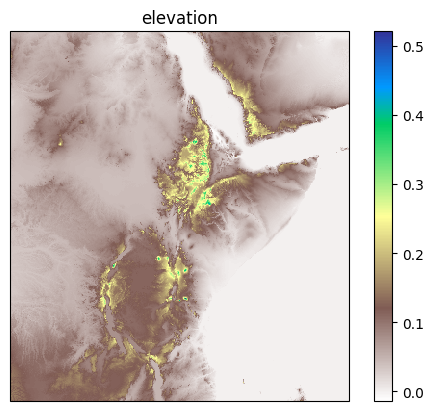

Text(0.5, 1.0, 'land-sea mask')

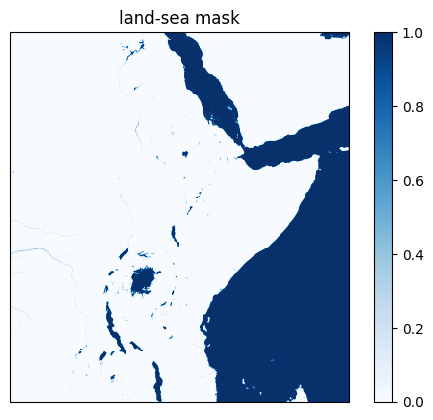

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

ax = plt.axes(projection = ccrs.PlateCarree())

lats = np.arange(-13.65,24.65+0.1,0.1)
lons = np.arange(19.15,54.25+0.1,0.1)

mesh = ax.pcolormesh(lons, lats, sample[0]['hi_res_inputs'][0,:,:,0], cmap='terrain_r')
plt.colorbar(mesh)
plt.title('elevation')
plt.show()
plt.close()

ax = plt.axes(projection = ccrs.PlateCarree())

mesh = ax.pcolormesh(lons, lats, sample[0]['hi_res_inputs'][0,:,:,1], cmap='Blues')
plt.colorbar(mesh)
plt.title('land-sea mask')

### Now we can try a variable such as surface pressure

Text(0.5, 1.0, 'sp mean')

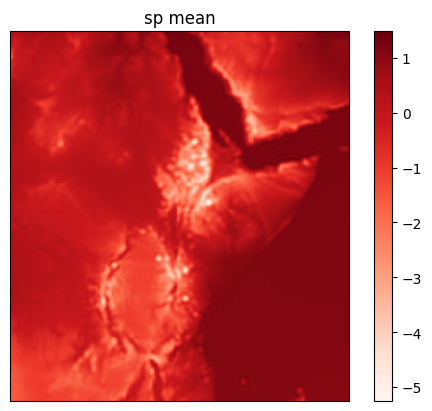

In [ ]:
# plot the variable mean for the first time step
# feel free to change the variables
var = "sp"
idx = all_fcst_fields.index(var)*4

ax = plt.axes(projection = ccrs.PlateCarree())

lats = np.arange(-13.65,24.65+0.1,0.1)
lons = np.arange(19.15,54.25+0.1,0.1)

mesh = ax.pcolormesh(lons, lats, sample[0]['lo_res_inputs'][0,:,:,idx], cmap='Reds')
plt.colorbar(mesh)
plt.title(f"{var} mean")

### Now we can start writing the tfrecord files by calling the ```write_data``` function. Good to know beforehand:
#### The ```write_data``` function is loaded from [**data/tfrecords_generator.py**](https://github.com/snath-xoc/cGAN_tutorial/blob/main/data/tfrecords_generator.py#L208). We write tfrecords into a file using the naming convention:

#### {year}_{leadtime}.{class}.tfrecords

#### Where the class represents a certain range of rainfall. The number of classes is specified under ```CLASSES``` in ```L23``` of the [**data/tfrecords_generator.py**](https://github.com/snath-xoc/cGAN_tutorial/blob/main/data/tfrecords_generator.py#L23), with the respective class bins specified under ```bins``` in [**data/tfrecords_generator.py**](https://github.com/snath-xoc/cGAN_tutorial/blob/main/data/tfrecords_generator.py#L226).

#### Typically we patch up the domain into **128x128 pixel** blocks during training, you can see this specified under ```DEFAULT_FCST_SHAPE```,  ```DEFAULT_CON_SHAPE``` and ```DEFAULT_OUT_SHAPE``` in [**data/tfrecords_generator.py**](https://github.com/snath-xoc/cGAN_tutorial/blob/main/data/tfrecords_generator.py#L24).

---

## NOTE:

The original write_data() function only processes 8 dates instead of all 365 dates for the year.

**Two options below:**
- **Option A:** Run original code
- **Option B:** Run over all 365 dates



---

### Option A: Original Code

In [ ]:

from data import write_data

years = [2018]

for year in years:
    # write_data(year)
    write_data(year, fcst_fields=FORECAST_VARIABLES)

Samples per image: 8
Doing time index 30


100%|██████████| 8/8 [00:09<00:00,  1.21s/it]


Doing time index 36


100%|██████████| 8/8 [00:10<00:00,  1.26s/it]


Doing time index 42


100%|██████████| 8/8 [00:09<00:00,  1.20s/it]


Doing time index 48


100%|██████████| 8/8 [00:10<00:00,  1.26s/it]


### Option B: (Processes ALL 365 dates) (10 mins)

In [ ]:
# Option B:(processes ALL 365 dates)
from data.tfrecords_generator import DataGeneratorFull, _float_feature, denormalise
from data import get_dates
import tensorflow as tf
import numpy as np
import random
from tqdm import tqdm
from datetime import datetime as dt

# Which lead times to process:
# Options: [30], [30, 36], [30, 36, 42, 48]
LEAD_TIMES = [30]

print(f"Year: {year}")
print(f"Lead times: {LEAD_TIMES}")
print(f"Output: {data_paths['TFRecords']['tfrecords_path']}")


import time
total_start = time.time()

# Settings
img_size_h, img_size_w = 384, 352
img_chunk_width = 128
num_class = 4
bins = [0.2, 0.3, 0.45]

for time_idx in LEAD_TIMES:
    print(f"\n{'='*70}")
    print(f"Processing time index {time_idx}h")
    print(f"{'='*70}")

    # Get dates for this lead time
    dates = get_dates(year, start_hour=time_idx, end_hour=time_idx+6)
    print(f"Dates to process: {len(dates)}")

    # Create data generator
    dgc = DataGeneratorFull(
        dates,
        fcst_fields=all_fcst_fields,
        start_hour=time_idx,
        end_hour=time_idx+6,
        batch_size=1,
        log_precip=True,
        shuffle=False,
        constants=True,
        fcst_norm=True,
    )

    # Open TFRecord writers (one per precipitation class)
    fle_hdles = []
    tfrecords_path = data_paths['TFRecords']['tfrecords_path']
    for fh in range(num_class):
        flename = os.path.join(tfrecords_path, f"{year}_{time_idx}.{fh}.tfrecords")
        options = tf.io.TFRecordOptions(compression_type="GZIP")
        fle_hdles.append(tf.io.TFRecordWriter(flename, options=options))

    samples_written = 0

    # Process ALL dates (fixed from original which only did 8)
    for batch_idx in tqdm(range(len(dates)), desc=f"{time_idx}h"):
        try:
            sample = dgc.__getitem__(batch_idx)

            # Create 8 random patches from each date
            for _ in range(8):
                idh = random.randint(0, img_size_h - img_chunk_width)
                idw = random.randint(0, img_size_w - img_chunk_width)

                mask = sample[1]["mask"][0, idh:idh+img_chunk_width, idw:idw+img_chunk_width].flatten()
                if np.any(mask):
                    continue  # Skip invalid patches

                truth = sample[1]["output"][0, idh:idh+img_chunk_width, idw:idw+img_chunk_width].flatten()
                const = sample[0]["hi_res_inputs"][0, idh:idh+img_chunk_width, idw:idw+img_chunk_width, :].flatten()
                forecast = sample[0]["lo_res_inputs"][0, idh:idh+img_chunk_width, idw:idw+img_chunk_width, :].flatten()

                # Create TFRecord example
                feature = {
                    "generator_input": _float_feature(forecast),
                    "constants": _float_feature(const),
                    "generator_output": _float_feature(truth),
                }
                example = tf.train.Example(features=tf.train.Features(feature=feature))

                # Classify by rainfall amount
                truth_raw = denormalise(truth)
                if len(truth_raw) == 0:
                    continue
                truth_mean = truth_raw.mean()

                if truth_mean < bins[0]:
                    clss = 0
                elif truth_mean < bins[1]:
                    clss = 1
                elif truth_mean < bins[2]:
                    clss = 2
                else:
                    clss = 3

                fle_hdles[clss].write(example.SerializeToString())
                samples_written += 1

        except FileNotFoundError as e:
            # Skip dates that need next year's data
            continue

    # Close files
    for fh in fle_hdles:
        fh.close()

    print(f"Completed {time_idx}h - {samples_written} samples written")


Year: 2018
Lead times: [30]
Output: /content/drive/MyDrive/my_tfrecords_2018/

Processing time index 30h
Dates to process: 365


30h: 100%|██████████| 365/365 [06:51<00:00,  1.13s/it]

Completed 30h - 2864 samples written


# Sanity read-in and batch check for once data is created

In [ ]:
import tensorflow as tf
from data import _parse_batch

tfrecords_path = data_paths["TFRecords"]["tfrecords_path"]

dataset = tf.data.TFRecordDataset(os.path.join(tfrecords_path,'2018_30.3.tfrecords'),compression_type='GZIP') #'2018_30.3.tfrecords'


In [ ]:
n_channels = len(all_fcst_fields) * 4
dataset = dataset.map(lambda x: _parse_batch(x, insize = (128,128,n_channels), consize=(128,128,2), outsize=(128,128,1)))
test = dataset.repeat().batch(2)
for inputs,outputs in test.take(1).as_numpy_iterator():

    print(inputs['lo_res_inputs'].shape)

    break

(2, 128, 128, 16)


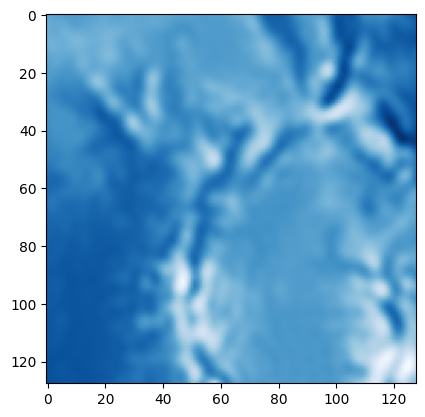

In [ ]:
import matplotlib.pyplot as plt
from data import all_fcst_fields

var = "sp"
idx = all_fcst_fields.index(var)*4
plt.imshow(inputs['lo_res_inputs'][0,:,:,idx],cmap='Blues')